<a href="https://colab.research.google.com/github/akira-616/mobile_user_behaviour_analysis/blob/main/mobile_behavoir_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB
User ID                       0
Device Model                  0
Operating System           

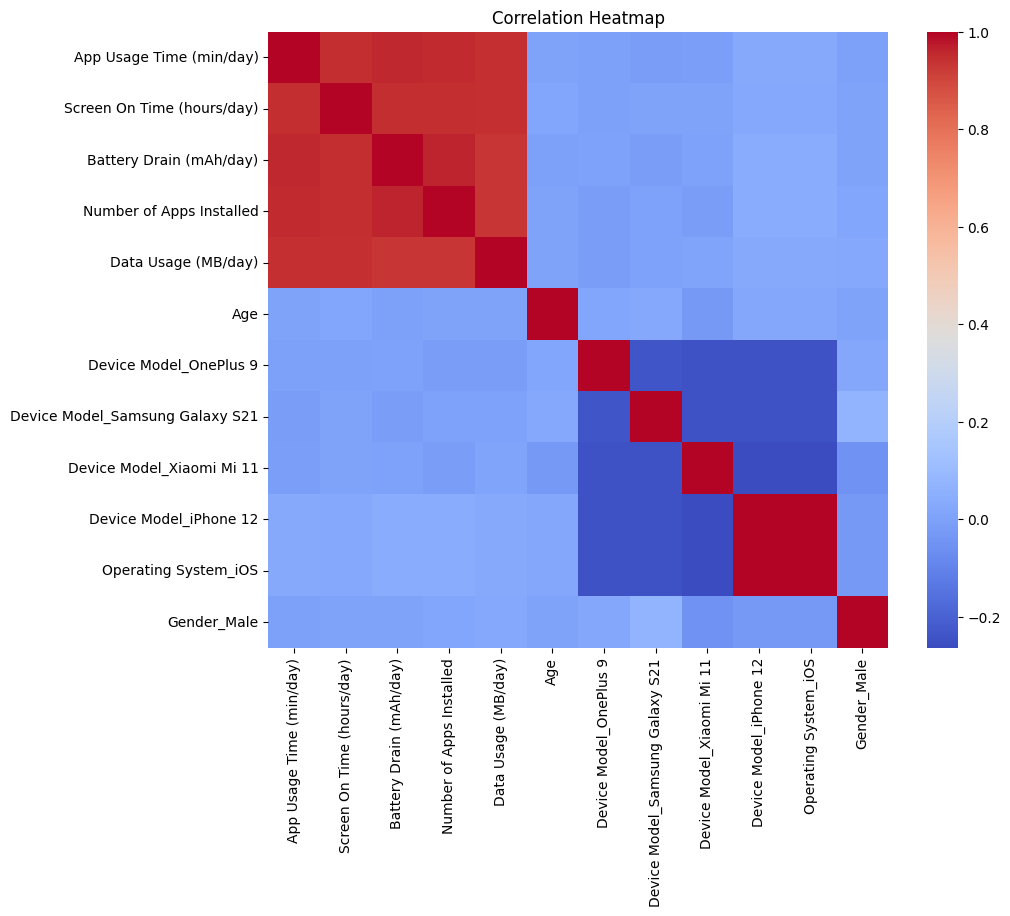

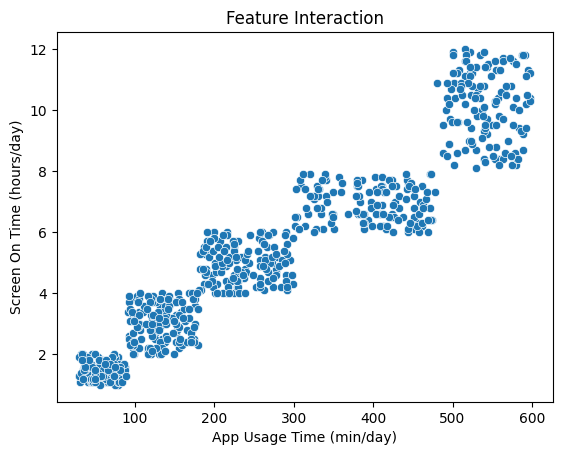

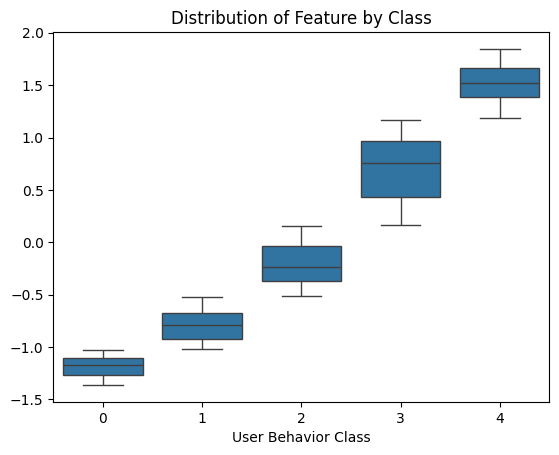

Model Accuracies:
{'Logistic Regression': 1.0, 'Decision Tree': 1.0, 'KNN': 0.9428571428571428}


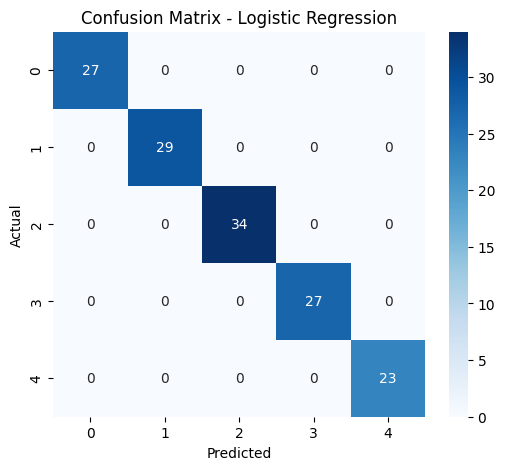

Logistic Regression CV Accuracy: 1.0000
Decision Tree CV Accuracy: 0.9971
KNN CV Accuracy: 0.9571


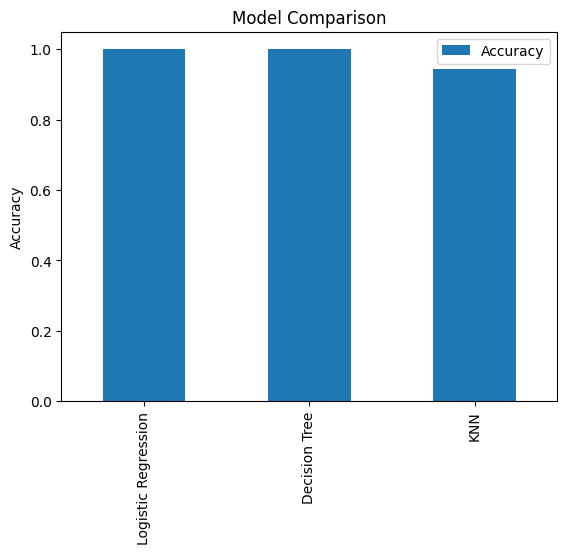

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("user_behavior_dataset.csv")
df.head()
df.info()
df.describe()

print(df.isnull().sum())
if "User ID" in df.columns:
    df = df.drop("User ID", axis=1)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["User Behavior Class"] = le.fit_transform(df["User Behavior Class"])
df = pd.get_dummies(df, drop_first=True)

from sklearn.preprocessing import StandardScaler
X = df.drop("User Behavior Class", axis=1)
y = df["User Behavior Class"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_scaled, columns=X.columns).corr(),
            annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(
    data = df,
    x=X.columns[0],
    y=X.columns[1],
)
plt.title("Feature Interaction")
plt.show()

sns.boxplot(x=y, y=X_scaled[:,0])
plt.title("Distribution of Feature by Class")
plt.show()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

print("Model Accuracies:")
print(results)

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")

comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
comparison_df.sort_values(by='Accuracy', ascending=False).plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()
